In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
data_path = "/Users/alexdimofte/workspace/northeastern/data/heldout360_all_probes.csv"
df = pd.read_csv(data_path)
df.head()


,name,size,complexity,step,abs_pos,token_idx,token,label,label_name,jlens_count,...,next_action_seeds.logitlens_l15_seed42_lr_p_true,next_action_seeds.logitlens_l15_seed42_mlp_p_true,next_action_seeds.logitlens_l15_seed43_lr_p_true,next_action_seeds.logitlens_l15_seed43_mlp_p_true,next_action_seeds.logitlens_l15_seed44_lr_p_true,next_action_seeds.logitlens_l15_seed44_mlp_p_true,next_action_seeds.random_l15_seed43_lr_p_true,next_action_seeds.random_l15_seed43_mlp_p_true,next_action_seeds.random_l15_seed44_lr_p_true,next_action_seeds.random_l15_seed44_mlp_p_true
0,together_ai_openai_gpt-oss-20b_size11_comp0.0_135,11,0.0,0,717,3,Agent,2,RIGHT,2,...,0.530493,0.997808,0.435654,0.952389,0.458239,0.996004,0.432621,0.966670,0.437646,0.991194
1,together_ai_openai_gpt-oss-20b_size11_comp0.0_135,11,0.0,0,718,4,Ġat,2,RIGHT,6,...,0.882422,0.998877,0.838088,0.999637,0.857087,0.999988,0.706122,0.996092,0.706853,0.998802
2,together_ai_openai_gpt-oss-20b_size11_comp0.0_135,11,0.0,0,719,5,Ġ(,2,RIGHT,11,...,0.708541,0.888800,0.631068,0.998941,0.655639,0.999040,0.589495,0.926143,0.460523,0.994247
3,together_ai_openai_gpt-oss-20b_size11_comp0.0_135,11,0.0,0,720,6,2,2,RIGHT,15,...,0.882634,1.000000,0.896479,0.999990,0.875726,1.000000,0.757281,0.999999,0.760631,0.999977
4,together_ai_openai_gpt-oss-20b_size11_comp0.0_135,11,0.0,0,721,7,",",2,RIGHT,15,...,0.618109,0.629604,0.547942,0.969360,0.552970,0.947047,0.282740,0.552657,0.477205,0.998133


In [124]:
# chain_len = max(token_idx) + 1
# completion_percent = token_idx / (chain_len - 1) *100

max_token_idx_per_name = df.groupby('name').max()['token_idx'] - 3
for name in max_token_idx_per_name.keys():
    df.loc[df['name'] == name, 'completion_percent'] = (df.loc[df['name'] == name, 'token_idx']-3) / (max_token_idx_per_name[name]) * 100

In [125]:
df['completion_percent'].describe()

count    87221.000000
mean        50.000000
std         28.988122
min          0.000000
25%         24.924012
50%         50.000000
75%         75.075988
max        100.000000
Name: completion_percent, dtype: float64

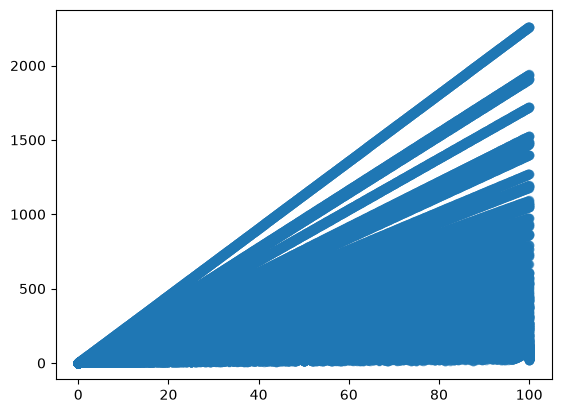

In [121]:
plt.scatter(df['completion_percent'], df['token_idx'], alpha=0.5)

In [94]:
df.columns

Index(['name', 'size', 'complexity', 'step', 'abs_pos', 'token_idx', 'token',
       'label', 'label_name', 'jlens_count', 'jlens_mass_L15',
       'jlens_mass_best_layer', 'jlens_mass_best', 'logitlens_count',
       'logitlens_mass_L15', 'logitlens_mass_best_layer',
       'logitlens_mass_best', 'next_action.jlens_topall_lr_pred',
       'next_action.jlens_topall_mlp_pred',
       'next_action.logitlens_topall_lr_pred',
       'next_action.logitlens_topall_mlp_pred',
       'next_action.random_topall_lr_pred',
       'next_action.random_topall_mlp_pred',
       'next_action_l15.jlens_topall_lr_pred',
       'next_action_l15.jlens_topall_mlp_pred',
       'next_action_mass_l15.jlens_topall_lr_pred',
       'next_action_mass_l15.jlens_topall_mlp_pred',
       'next_action_mass_l15.random_topall_lr_pred',
       'next_action_mass_l15.random_topall_mlp_pred',
       'next_action_seeds.jlens_l15_seed43_lr_pred',
       'next_action_seeds.jlens_l15_seed43_mlp_pred',
       'next_action_see

In [107]:
df['completion_percent'].describe()

count    87221.000000
mean        50.604128
std         28.648698
min          0.132626
25%         25.824742
50%         50.617284
75%         75.415896
max        100.000000
Name: completion_percent, dtype: float64

(array([1048.,  859.,  869.,  872.,  860.,  876.,  874.,  865.,  875.,
         847.,  901.,  841.,  887.,  865.,  850.,  875.,  897.,  854.,
         869.,  831.,  895.,  880.,  859.,  862.,  835.,  919.,  865.,
         864.,  870.,  848.,  895.,  850.,  884.,  874.,  858.,  868.,
         875.,  872.,  874.,  826.,  898.,  869.,  871.,  860.,  872.,
         869.,  869.,  865.,  872.,  785.,  968.,  855.,  882.,  861.,
         858.,  874.,  879.,  871.,  867.,  818.,  906.,  866.,  880.,
         858.,  866.,  869.,  882.,  867.,  867.,  855.,  890.,  851.,
         881.,  857.,  830.,  915.,  879.,  851.,  888.,  815.,  911.,
         861.,  862.,  880.,  873.,  861.,  873.,  870.,  858.,  861.,
         887.,  858.,  882.,  866.,  865.,  862.,  889.,  861.,  867.,
        1050.]),
 array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
         11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
         22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.

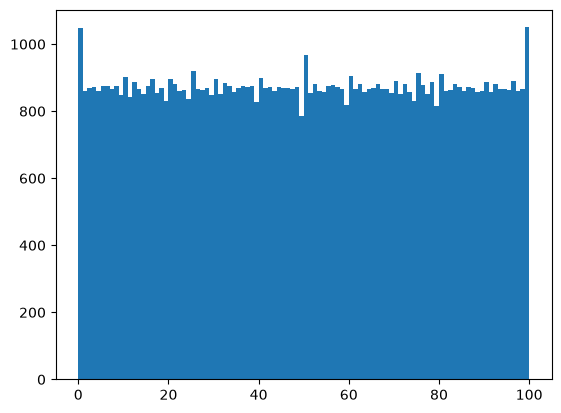

In [127]:
plt.hist(df['completion_percent'], bins=100)

(array([46365., 18304.,  8373.,  5409.,  3798.,  2118.,  1356.,   816.,
          456.,   226.]),
 array([   3. ,  228.9,  454.8,  680.7,  906.6, 1132.5, 1358.4, 1584.3,
        1810.2, 2036.1, 2262. ]),
 <BarContainer object of 10 artists>)

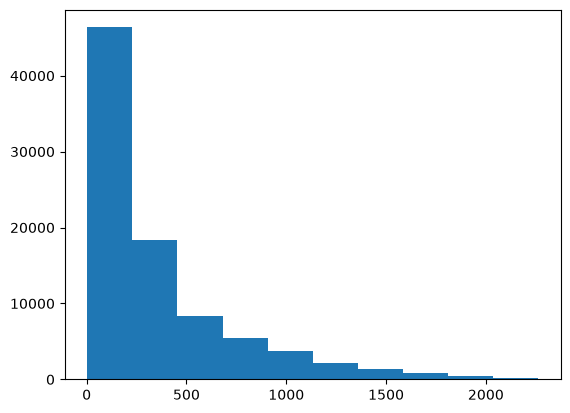

In [128]:
plt.hist(df['token_idx'])

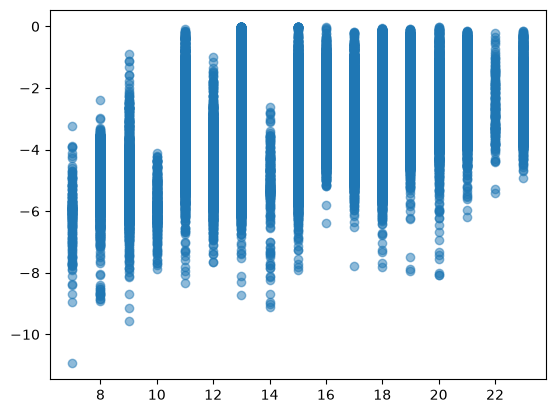

In [129]:
# df['jlens_count'], df['jlens_mass_L15'], df['jlens_mass_best_layer']

plt.scatter(df['jlens_mass_best_layer'], df['jlens_mass_L15'], alpha=0.5)

<Axes: xlabel='jlens_mass_L15', ylabel='token'>

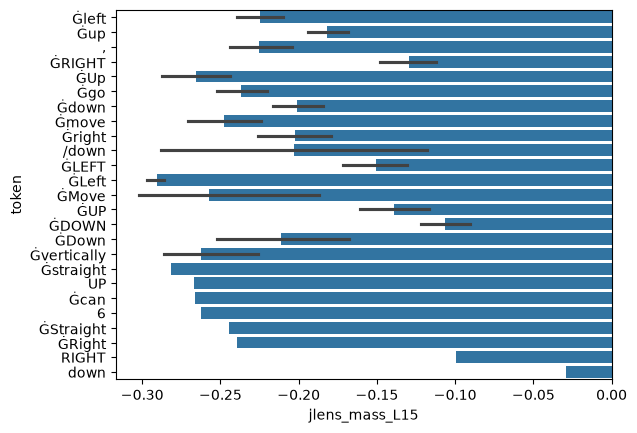

In [180]:
df_top_20 = df.sort_values(by='jlens_mass_L15', ascending=False).head(700)
df_in_use = df_top_20
# plt.bar(height=df_in_use['jlens_count'], x=df_in_use['token'])
# plot with tokens on the y axis, and jlens mass best layer on the x axis in ascending order
sns.barplot(y="token", x="jlens_mass_L15", data=df_in_use.sort_values(by='jlens_mass_L15', ascending=True))
# sns.scatterplot(x='jlens_count', y='jlens_mass_L15', data=df_in_use)

<Axes: >

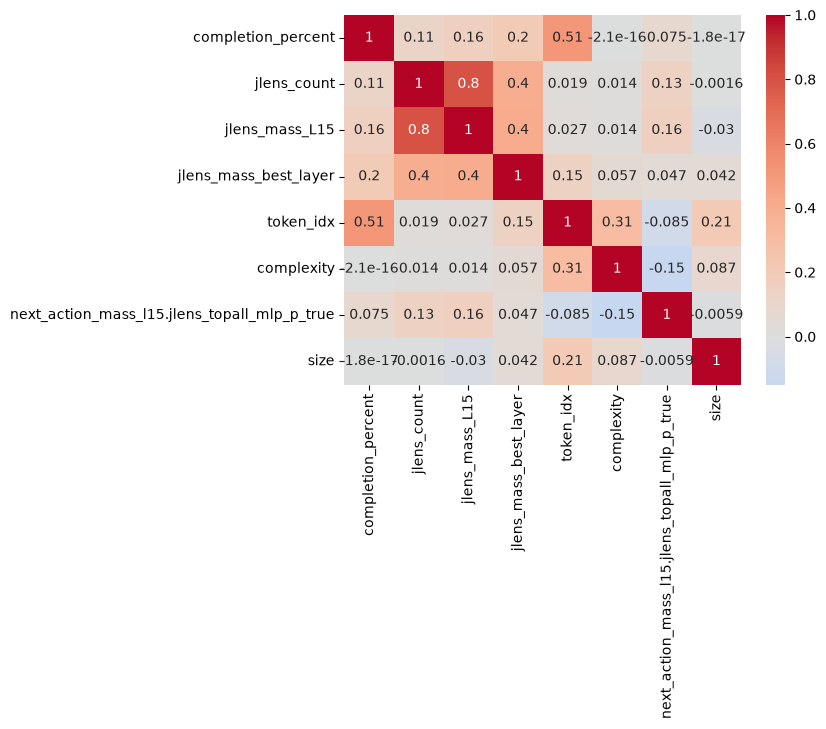

In [198]:
df_in_use = df.sort_values(by='jlens_mass_L15', ascending=True)
df_in_use = df_in_use[['completion_percent', 'jlens_count', 'jlens_mass_L15', 'jlens_mass_best_layer', 'token_idx', 'complexity', 'next_action_mass_l15.jlens_topall_mlp_p_true', 'size']]
sns.heatmap(df_in_use.corr(), annot=True, cmap='coolwarm', center=0)

In [185]:
df_in_use.sort_values(by='jlens_mass_L15', ascending=False).head(20)[['token', 'jlens_mass_L15', 'completion_percent']]

,token,jlens_mass_L15,completion_percent
43668,ĠRIGHT,-0.006937,89.156627
2399,ĠDOWN,-0.008852,99.159664
43139,ĠDOWN,-0.010172,90.833333
48735,ĠLEFT,-0.012606,67.105263
58986,ĠRIGHT,-0.013514,86.279070
43867,ĠLEFT,-0.014624,87.735849
77773,ĠRIGHT,-0.015200,95.333333
75764,ĠDOWN,-0.015827,99.588477
8249,ĠDOWN,-0.017189,98.358503
47211,ĠDOWN,-0.017242,64.265130


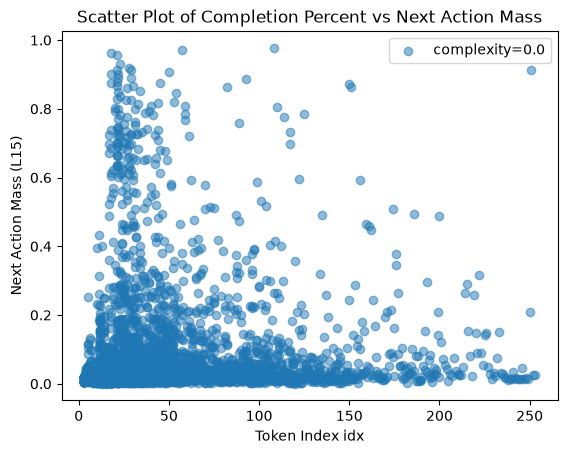

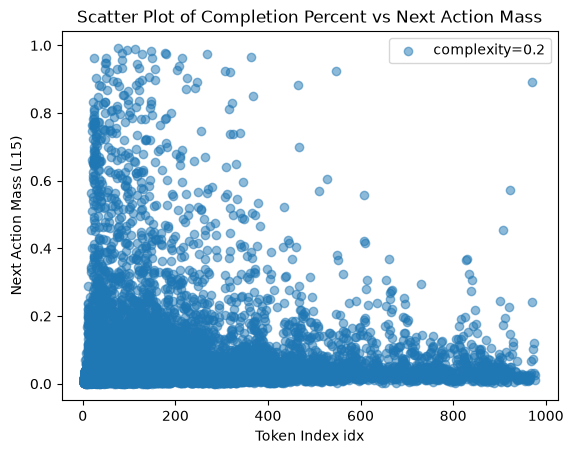

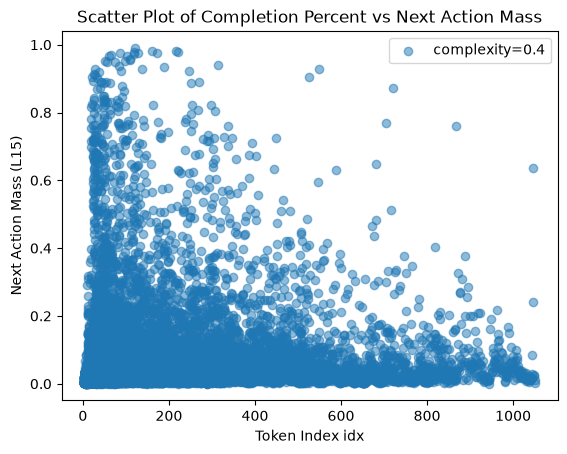

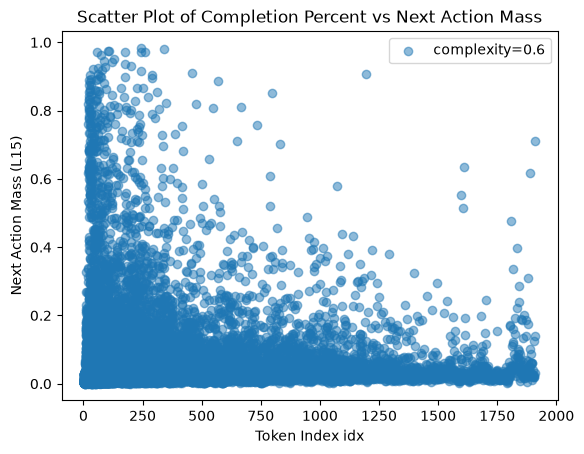

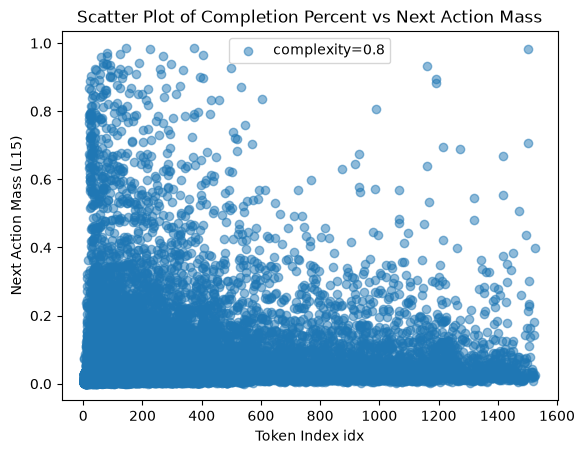

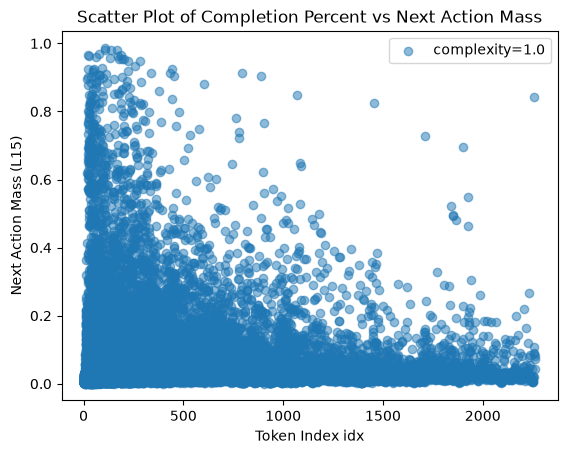

In [141]:
for complexity in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    df_filtered = df_in_use[df_in_use['complexity'] == complexity]
    plt.figure()
    plt.scatter(df_filtered['token_idx'], np.exp(df_filtered['jlens_mass_L15']), alpha=0.5, label=f'complexity={complexity}')

    plt.xlabel('Token Index idx')
    plt.ylabel('Next Action Mass (L15)')
    plt.title('Scatter Plot of Completion Percent vs Next Action Mass')
    plt.legend()
    plt.show()

# sns.scatterplot(x='jlens_mass_L15', y='next_action_mass_l15.jlens_topall_mlp_p_true', data=df_in_use)

/var/folders/qs/0q06h0s57kl03gnbz11ds7cw0000gn/T/ipykernel_88736/3269476873.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


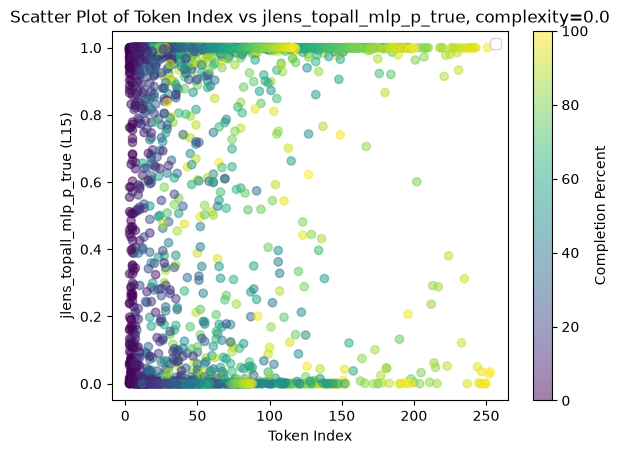

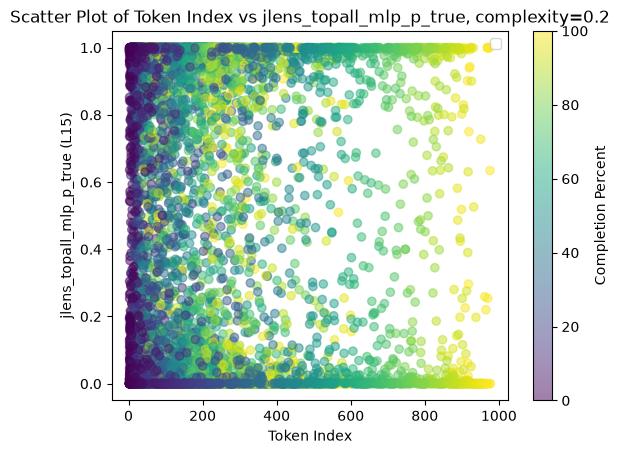

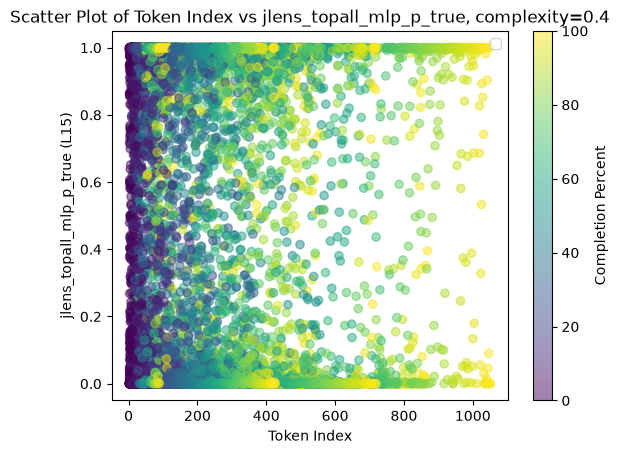

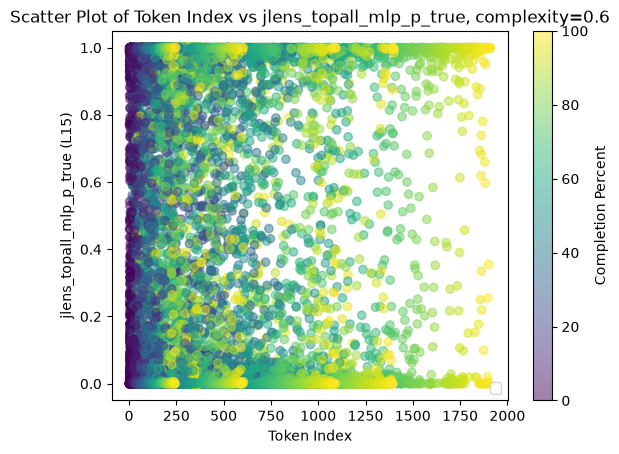

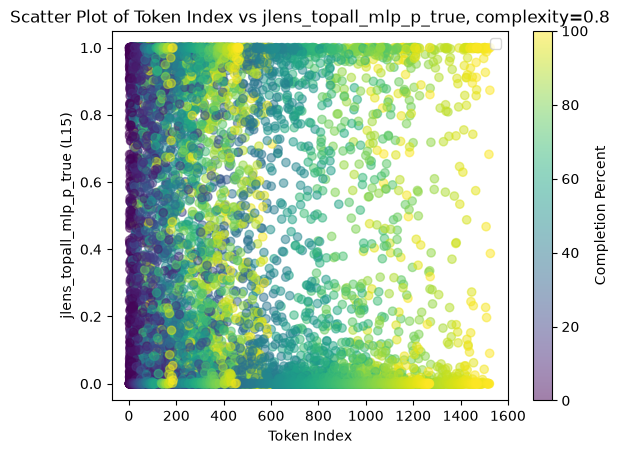

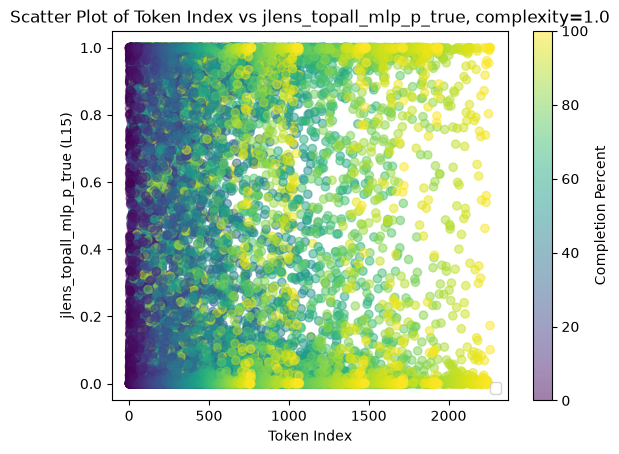

In [159]:
for complexity in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    df_filtered = df_in_use[df_in_use['complexity'] == complexity]
    plt.figure()
    plt.scatter(df_filtered['token_idx'], df_filtered['next_action_mass_l15.jlens_topall_mlp_p_true'], alpha=0.5, c=df_filtered['completion_percent'], cmap='viridis')

    plt.xlabel('Token Index')
    plt.ylabel('jlens_topall_mlp_p_true (L15)')
    plt.title(f'Scatter Plot of Token Index vs jlens_topall_mlp_p_true, complexity={complexity}')
    # add color bar to show completion percent
    cbar = plt.colorbar()
    cbar.set_label('Completion Percent')
    plt.legend()
    plt.show()

# sns.scatterplot(x='jlens_mass_L15', y='next_action_mass_l15.jlens_topall_mlp_p_true', data=df_in_use)

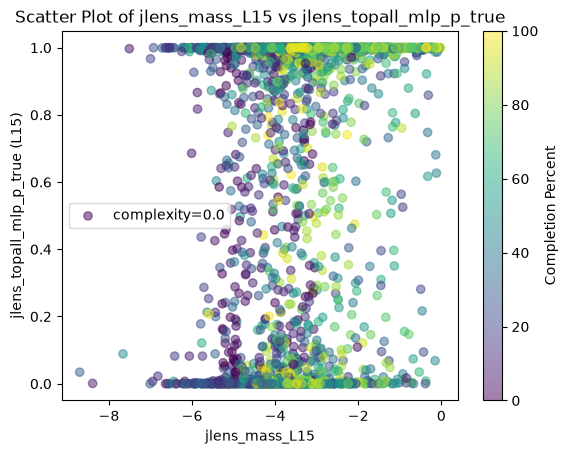

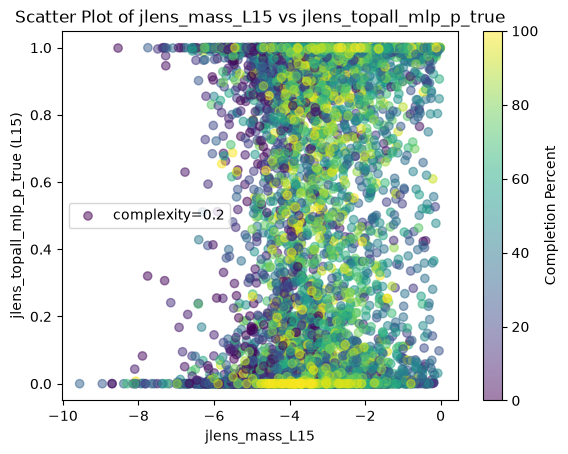

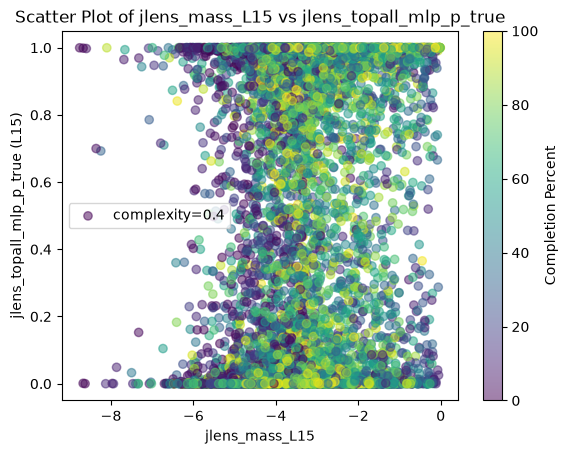

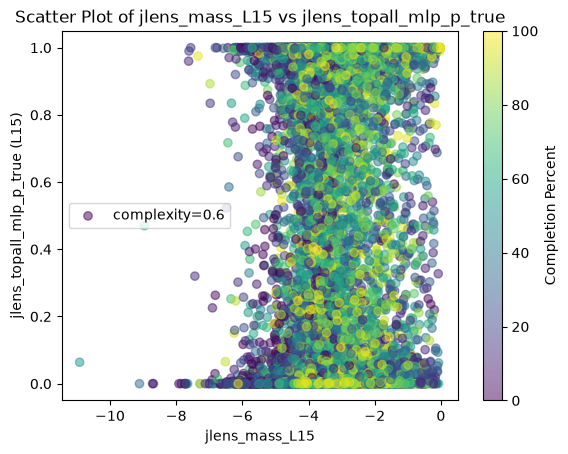

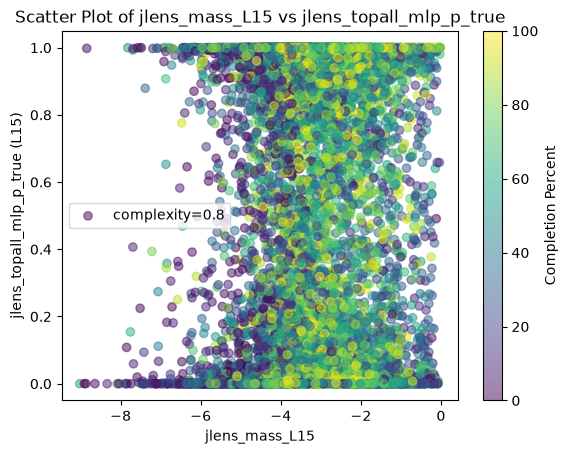

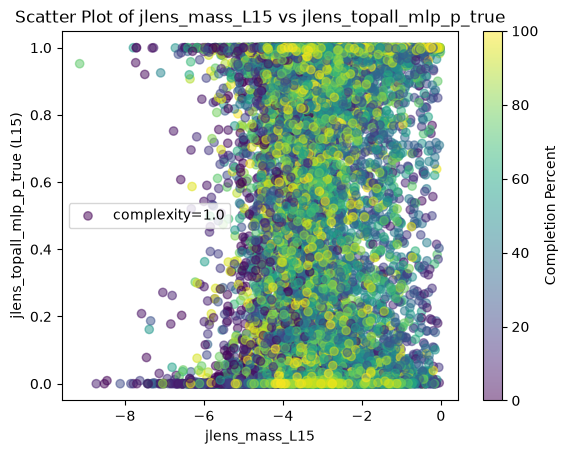

In [157]:
for complexity in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    df_filtered = df_in_use[df_in_use['complexity'] == complexity]
    plt.figure()
    plt.scatter(df_filtered['jlens_mass_L15'], df_filtered['next_action_mass_l15.jlens_topall_mlp_p_true'], alpha=0.5, label=f'complexity={complexity}', c=df_filtered['completion_percent'], cmap='viridis')

    plt.xlabel('jlens_mass_L15')
    plt.ylabel('jlens_topall_mlp_p_true (L15)')
    plt.title('Scatter Plot of jlens_mass_L15 vs jlens_topall_mlp_p_true')
    # colorbar
    cbar = plt.colorbar()
    cbar.set_label('Completion Percent')
    plt.legend()
    plt.show()

# sns.scatterplot(x='jlens_mass_L15', y='next_action_mass_l15.jlens_topall_mlp_p_true', data=df_in_use)
